## Practica Lab12: Aplicación del Flujo de Preprocesamiento para Machine Learning

## Dataset: Adult Income

**Download latest version**

path = kagglehub.dataset_download("uciml/adult-census-income")

---

## Objetivo

Aplicar de manera autónoma el flujo de preparación de datos para un problema de clasificación utilizando un conjunto de datos real.

Al finalizar la práctica, el estudiante será capaz de:

1. Importación de librerías
2. Carga del dataset
3. Comprensión del problema
4. Exploración inicial (EDA)
5. Correlación e hipótesis
6. Variables predictoras y objetivo
7. Tratamiento de nulos
8. One-Hot Encoding
9. Train/Test Split
10. StandardScaler
11. Árbol de Decisión
12. Predicciones
13. Accuracy
14. Feature Importance
15. Conclusiones

---

# Contexto del Problema

Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K


## Preguntas

1. ¿Cuál es la variable objetivo? R: income
2. ¿Qué representa dicha variable? R: El ingreso de las personas 
3. ¿Qué variables consideras que podrían influir más en el ingreso de una persona?
4. ¿Cuántas variables predictoras existen?
5. ¿Por qué fue necesario transformar variables categóricas?
7. ¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?
8. ¿Existen valores nulos?
9. ¿Qué variables son numéricas?
10. ¿Qué variables son categóricas?
11. ¿Cuántos registros quedaron en entrenamiento?
12. ¿Cuántos registros quedaron en prueba?
13. ¿Por qué no debemos entrenar utilizando todos los datos?
14. ¿Cuál fue el Accuracy obtenido?
15. ¿Consideras que el resultado es adecuado?
16. ¿Qué factores podrían afectar el desempeño del modelo?
18. ¿Cuál fue la variable más importante?
19. ¿Cuál fue la menos importante?
20. ¿Coinciden los resultados con tus hipótesis iniciales?
21. ¿Qué variables aportan más información al modelo?


# Entregables

El repositorio deberá contener:

```text
Notebooks/
└── Laboratorio12.ipynb
```

---


In [1]:
# immportar librerias

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub

C:\Users\tinn\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path = kagglehub.dataset_download("uciml/adult-census-income")

In [3]:
print("Ruta del dataset:", path)

Ruta del dataset: C:\Users\tinn\.cache\kagglehub\datasets\uciml\adult-census-income\versions\3


In [4]:
dfAdultosIngresos = pd.read_csv(path + "/adult.csv")

In [5]:
dfAdultosIngresos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
dfAdultosIngresos.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Parte 1. Comprensión del problema
Una institución financiera desea analizar las características de distintos individuos para determinar qué factores están asociados con ingresos superiores a $50,000 dólares anuales.

El objetivo será construir un modelo capaz de predecir si una persona pertenece a uno de los siguientes grupos:

- (<=) 50K
- (>) 50K

nuestra variable Y es **income**

In [7]:
# ver la distribucion de income
dfAdultosIngresos["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

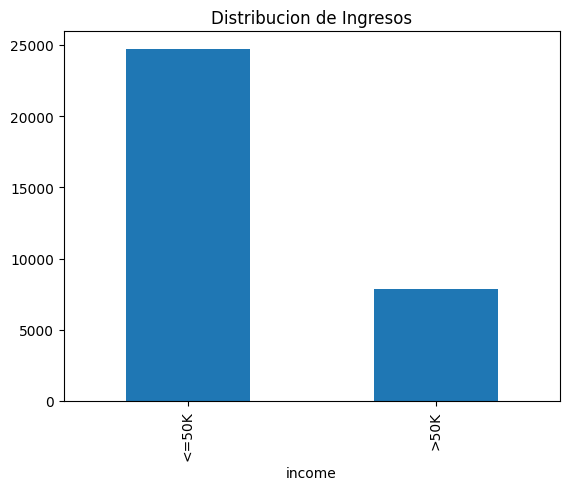

In [8]:
# graficamos
dfAdultosIngresos["income"].value_counts().plot(
    kind = "bar"
)
plt.title("Distribucion de Ingresos")
plt.show()

In [9]:
dfAdultosIngresos.replace("?", np.nan, inplace=True) # quitar los ?

In [10]:
dfAdultosIngresos.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Parte 2. Exploración inicial

In [11]:
pd.set_option('display.float_format', lambda x: '%.4f' % x)
dfAdultosIngresos.describe() # solo numéricas por defecto

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.0000,32561.0000,32561.0000,32561.0000,32561.0000,32561.0000
mean,38.5816,189778.3665,10.0807,1077.6488,87.3038,40.4375
std,13.6404,105549.9777,2.5727,7385.2921,402.9602,12.3474
min,17.0000,12285.0000,1.0000,0.0000,0.0000,1.0000
25%,28.0000,117827.0000,9.0000,0.0000,0.0000,40.0000
50%,37.0000,178356.0000,10.0000,0.0000,0.0000,40.0000
75%,48.0000,237051.0000,12.0000,0.0000,0.0000,45.0000
max,90.0000,1484705.0000,16.0000,99999.0000,4356.0000,99.0000


In [12]:
dfAdultosIngresos.groupby("sex")["income"].apply(lambda x: (x == ">50K").mean()) 
# taza de ingreso por sexo, de los que ganan +50k
# 10.95% de mujeres  30.57% de hombres tienen ingresos +50k

sex
Female   0.1095
Male     0.3057
Name: income, dtype: float64

## Parte 3. Correlación e hipótesis

Creamos una matriz de correlación para identificar la relación lineal entre las variables numéricas.

*Nota: la correlación lineal no identifica la importancia real de las variables en el modelo; `income` es categórica, por lo que no se incluye directamente en esta matriz.*

In [13]:
# variables numericas para analizar correlacion
variables_numericas = [
    "age",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [14]:
# matriz de correlacion
corr = dfAdultosIngresos[variables_numericas].corr()
corr

,age,education.num,capital.gain,capital.loss,hours.per.week
age,1.0000,0.0365,0.0777,0.0578,0.0688
education.num,0.0365,1.0000,0.1226,0.0799,0.1481
capital.gain,0.0777,0.1226,1.0000,-0.0316,0.0784
capital.loss,0.0578,0.0799,-0.0316,1.0000,0.0543
hours.per.week,0.0688,0.1481,0.0784,0.0543,1.0000


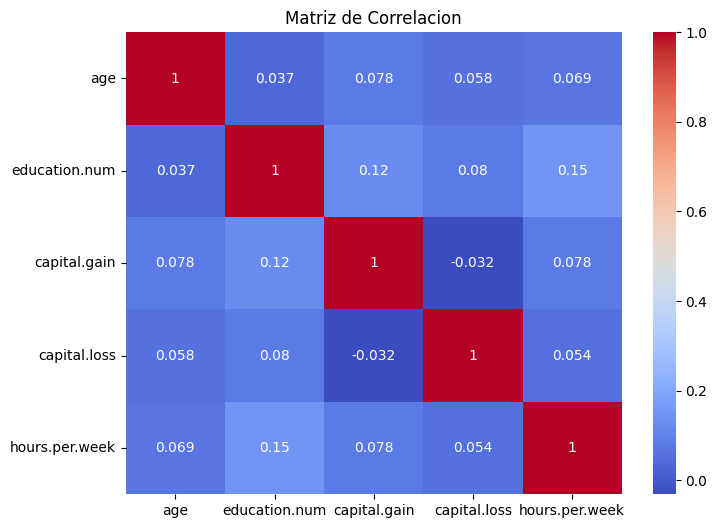

In [15]:
# graficamos la matriz de correlacion
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de Correlacion")
plt.show()

**Hipótesis:** `education.num`, `capital.gain` y `hours.per.week` son las variables numéricas con mayor relación positiva entre sí, por lo que se espera que también estén asociadas con mayores ingresos (`income`).

## Parte 4. Selección de variables predictoras y objetivo

- **X** — Variables predictoras (características que usará el modelo)
- **Y** — Variable objetivo (lo que queremos predecir: `income`)

Se excluyen `fnlwgt` (peso muestral, no describe a la persona), `education` (redundante con `education.num`) y `native.country` (alta cardinalidad, ~40 categorías) para mantener el modelo simple, igual que en Lab11 se excluyeron `PassengerId`, `Name`, `Ticket` y `Cabin`.

In [16]:
# columnas predictoras seleccionadas
columnas = [
    "age",
    "workclass",
    "education.num",
    "marital.status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [17]:
# definimos x y
X = dfAdultosIngresos[columnas]
Y = dfAdultosIngresos["income"]

In [18]:
print(X.columns.tolist())
print(Y.name)

['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week']
income


## Parte 5. Tratamiento de valores faltantes

Para simplificar el proceso, realizaremos la imputación de los datos antes de la separación Train/Test. Las columnas categóricas `workclass` y `occupation` tienen valores nulos (originalmente `"?"`) que se imputan con la moda, igual que se hizo con `Embarked` en Lab11.

In [19]:
# revisamos valores nulos en las predictoras
X.isnull().sum()

age                  0
workclass         1836
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
dtype: int64

In [20]:
# imputamos con la moda (valor mas frecuente) las columnas categoricas con nulos
X["workclass"] = X["workclass"].fillna(
    X["workclass"].mode()[0]
)

X["occupation"] = X["occupation"].fillna(
    X["occupation"].mode()[0]
)

C:\Users\tinn\AppData\Local\Temp\ipykernel_2000\1638531576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["workclass"] = X["workclass"].fillna(
C:\Users\tinn\AppData\Local\Temp\ipykernel_2000\1638531576.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["occupation"] = X["occupation"].fillna(


In [21]:
# verificamos que ya no existan nulos
X.isnull().sum()

age               0
workclass         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
dtype: int64

## Parte 6. Codificación de variables categóricas

Los algoritmos no entienden texto directamente. Convertimos las variables categóricas (`workclass`, `marital.status`, `occupation`, `relationship`, `race`, `sex`) en variables numéricas mediante One-Hot Encoding.

In [22]:
# one-hot encoding de las variables categoricas
X = pd.get_dummies(
    X,
    columns=["workclass","marital.status","occupation","relationship","race","sex"],
    drop_first=True
)

In [23]:
X.head()

,age,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male
0,90,9,0,4356,40,False,False,True,False,False,...,True,False,False,False,False,False,False,False,True,False
1,82,9,0,4356,18,False,False,True,False,False,...,True,False,False,False,False,False,False,False,True,False
2,66,10,0,4356,40,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
3,54,4,0,3900,40,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
4,41,10,0,3900,40,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,False


## Parte 7. Partición de los datos

No debemos entrenar y evaluar el modelo con los mismos datos. La recomendación estándar es:

- **Entrenamiento:** 80%
- **Prueba:** 20%

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size = 0.20,
    random_state=42
)

In [25]:
print("Entrenamiento:", X_train.shape)
print("Prueba:", y_test.shape)

Entrenamiento: (26048, 41)
Prueba: (6513,)


## Parte 8. Escalado de las variables

Las variables numéricas tienen escalas distintas (`age` vs `capital.gain`, por ejemplo). El escalado (StandardScaler) evita que una variable con valores grandes domine sobre las demás.

In [26]:
# columnas numericas a escalar
columnas_numericas = [
    "age",
    "education.num",
    "capital.gain",
    "capital.loss",
    "hours.per.week"
]

In [27]:
# estadisticas antes de escalar
X_train[columnas_numericas].describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,26048.0000,26048.0000,26048.0000,26048.0000,26048.0000
mean,38.5269,10.0883,1106.4656,88.5506,40.5190
std,13.5876,2.5807,7518.6114,406.8010,12.3327
min,17.0000,1.0000,0.0000,0.0000,1.0000
25%,28.0000,9.0000,0.0000,0.0000,40.0000
50%,37.0000,10.0000,0.0000,0.0000,40.0000
75%,47.0000,13.0000,0.0000,0.0000,45.0000
max,90.0000,16.0000,99999.0000,4356.0000,99.0000


In [28]:
# ajustamos el escalador con train y transformamos train/test
scaler = StandardScaler()
X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)

X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

In [29]:
# estadisticas despues de escalar (media ~0, desviacion ~1)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
X_train[columnas_numericas].describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,26048.0000,26048.0000,26048.0000,26048.0000,26048.0000
mean,-0.0000,0.0000,-0.0000,-0.0000,0.0000
std,1.0000,1.0000,1.0000,1.0000,1.0000
min,-1.5843,-3.5217,-0.1472,-0.2177,-3.2045
25%,-0.7748,-0.4217,-0.1472,-0.2177,-0.0421
50%,-0.1124,-0.0342,-0.1472,-0.2177,-0.0421
75%,0.6236,1.1283,-0.1472,-0.2177,0.3634
max,3.7883,2.2907,13.1533,10.4905,4.7421


In [30]:
# verificamos que el mismo escalado se aplico al conjunto de prueba
X_test[columnas_numericas].describe()

,age,education.num,capital.gain,capital.loss,hours.per.week
count,6513.0000,6513.0000,6513.0000,6513.0000,6513.0000
mean,0.0201,-0.0148,-0.0192,-0.0153,-0.0330
std,1.0192,0.9844,0.9078,0.9519,1.0056
min,-1.5843,-3.5217,-0.1472,-0.2177,-3.2045
25%,-0.8484,-0.4217,-0.1472,-0.2177,-0.0421
50%,-0.1124,-0.0342,-0.1472,-0.2177,-0.0421
75%,0.6972,0.7408,-0.1472,-0.2177,0.3634
max,3.7883,2.2907,13.1533,9.0499,4.7421


## Parte 9. Entrenamiento del modelo

Usaremos un árbol de decisión para clasificar si una persona gana `<=50K` o `>50K`.

In [31]:
# creamos el modelo de arbol de decision
modelo = DecisionTreeClassifier(
    max_depth = 4,
    random_state = 42
)

In [32]:
# entrenamos el modelo con los datos de entrenamiento
modelo.fit(
    X_train,
    y_train
)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Parte 10. Evaluación del modelo

Realizamos predicciones sobre el conjunto de prueba para evaluar el rendimiento del modelo.

In [33]:
# predicciones sobre el conjunto de prueba
predicciones = modelo.predict(
    X_test
)

In [34]:
# comparamos valores reales vs predichos
pd.DataFrame({
    "Real": y_test,
    "Predicción": predicciones
}).head(35)

,Real,Predicción
14160,<=50K,<=50K
27048,<=50K,<=50K
28868,<=50K,<=50K
5667,<=50K,<=50K
7827,<=50K,<=50K
15382,<=50K,<=50K
4641,<=50K,<=50K
8943,<=50K,<=50K
216,<=50K,<=50K
5121,<=50K,<=50K


## Parte 11. Interpretación del accuracy

El **accuracy** mide el porcentaje de predicciones correctas realizadas por el modelo sobre el total.

| Precisión (Accuracy) | Interpretación |
|---|---|
| 50% | Adivina (aleatorio) |
| 0–70% | Aceptable / Básico |
| 70–80% | Bueno |
| 80–90% | Muy bueno |
| >90% | Excelente (posible sobreajuste) |

In [35]:
# calculamos el accuracy del modelo
accuracy = accuracy_score(
    y_test,
    predicciones
)

In [36]:
print(f"Accuracy: {accuracy: .4f}")

Accuracy:  0.8449


## Parte 12. Importancia de las variables

Analizamos qué variables fueron más relevantes para el árbol de decisión al realizar las predicciones.

In [37]:
importancias = pd.DataFrame({
	"Variable" : X_train.columns,
	"Importancia" : modelo.feature_importances_ # que variable es importante para el modelo
})

In [38]:
importancias.sort_values(
    by = "Importancia",
    ascending = False
)

,Variable,Importancia
13,marital.status_Married-civ-spouse,0.4917
1,education.num,0.2483
2,capital.gain,0.2268
3,capital.loss,0.0218
0,age,0.0112
21,occupation_Farming-fishing,0.0002
6,workclass_Never-worked,0.0000
5,workclass_Local-gov,0.0000
4,hours.per.week,0.0000
8,workclass_Self-emp-inc,0.0000


## Parte 13. Conclusiones

**Respuestas a las preguntas:**

1. **¿Cuál es la variable objetivo?** `income`.
2. **¿Qué representa dicha variable?** Si el ingreso anual de la persona es `<=50K` o `>50K` dólares.
3. **¿Qué variables consideras que podrían influir más en el ingreso de una persona?** Antes de entrenar se hipotetizó que `education.num`, `hours.per.week`, `occupation` y `capital.gain` serían las más influyentes.
4. **¿Cuántas variables predictoras existen?** 11: `age`, `workclass`, `education.num`, `marital.status`, `occupation`, `relationship`, `race`, `sex`, `capital.gain`, `capital.loss`, `hours.per.week`.
5. **¿Por qué fue necesario transformar variables categóricas?** Porque el árbol de decisión de scikit-learn solo trabaja con valores numéricos; el texto (`workclass`, `marital.status`, etc.) debe convertirse mediante One-Hot Encoding.
7. **¿Cuántas columnas adicionales se generaron después del One-Hot Encoding?** X pasó de 11 a 41 columnas, es decir, 30 columnas adicionales.
8. **¿Existen valores nulos?** Sí: `workclass` tenía 1,836 nulos y `occupation` 1,843 nulos (originalmente representados como `"?"`), imputados con la moda.
9. **¿Qué variables son numéricas?** `age`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week` (además de `fnlwgt`, excluida del modelo por no ser una característica de la persona).
10. **¿Qué variables son categóricas?** `workclass`, `marital.status`, `occupation`, `relationship`, `race`, `sex` (además de `education` y `native.country`, excluidas del modelo por redundancia y alta cardinalidad).
11. **¿Cuántos registros quedaron en entrenamiento?** 26,048 (80%).
12. **¿Cuántos registros quedaron en prueba?** 6,513 (20%).
13. **¿Por qué no debemos entrenar utilizando todos los datos?** Porque se necesita un conjunto de datos que el modelo no haya visto durante el entrenamiento para medir su capacidad real de generalización y detectar sobreajuste.
14. **¿Cuál fue el Accuracy obtenido?** 0.8449 (84.49%).
15. **¿Consideras que el resultado es adecuado?** Según la tabla de interpretación (80–90% = "Muy bueno") es un resultado adecuado, aunque debe tomarse con cautela porque `income` está desbalanceado (~76% `<=50K` vs ~24% `>50K`), lo que puede inflar el accuracy.
16. **¿Qué factores podrían afectar el desempeño del modelo?** El desbalance de clases, la exclusión de `native.country` y `education`, la profundidad limitada del árbol (`max_depth=4`) y la imputación por moda en `workclass`/`occupation`.
18. **¿Cuál fue la variable más importante?** `marital.status_Married-civ-spouse` (0.4917), seguida de `education.num` (0.2483) y `capital.gain` (0.2268).
19. **¿Cuál fue la menos importante?** La mayoría de las columnas de `workclass`, `occupation`, `relationship`, `race`, `sex` y también `hours.per.week`, con importancia de 0.0000 (el árbol, con solo profundidad 4, no las usó en ningún split).
20. **¿Coinciden los resultados con tus hipótesis iniciales?** Parcialmente: `education.num` y `capital.gain` sí resultaron relevantes como se esperaba, pero `hours.per.week` —hipotetizada como relevante por su correlación con otras variables numéricas— terminó con importancia 0, mientras que `marital.status` (variable categórica no considerada en la hipótesis de correlación numérica) resultó ser la más determinante.
21. **¿Qué variables aportan más información al modelo?** `marital.status`, `education.num` y `capital.gain` concentran más del 94% de la importancia total del árbol.